In [40]:
import geopandas as gpd
import rasterio
from rasterio.mask import mask
from collections import Counter

from shapely.geometry import box
from shapely.ops import unary_union
from shapely import Polygon, MultiPolygon
import rioxarray

import os.path as path
import utils
import rioxarray as rxr
from rioxarray.merge import merge_arrays

import shapely
import xarray as xr
import numpy as np
import json
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon as MplPolygon
from concurrent.futures import ThreadPoolExecutor, as_completed

In [2]:
crop_type_files = utils.get_dataset_by_name("Crop Types")

In [3]:
gdf_polygons = gpd.read_file(path.join(utils.raw_data_dir, "NUTS_RG_01M_2024_4326.shp"))

In [4]:
with rasterio.open(crop_type_files[0]) as src:
    raster_crs = src.crs
gdf_polygons = gdf_polygons.to_crs(raster_crs)
assert raster_crs == gdf_polygons.crs

In [5]:
gdf_polygons = gdf_polygons[gdf_polygons["LEVL_CODE"] == 3]

In [6]:
print("building tile index...")
records = []
for i, filepath in enumerate(crop_type_files):
    if i % 100 == 0:
        print(f"processing file {i} of {len(crop_type_files)}")
    with rasterio.open(filepath) as src:
        records.append({
            "path": filepath,
            "geometry": box(*src.bounds),
            "crs": src.crs,
            "bounds": src.bounds
        })

print("Indexing...")
tile_index = gpd.GeoDataFrame(records, crs=records[0]["crs"])
print("Done.")

building tile index...
processing file 0 of 850
processing file 100 of 850
processing file 200 of 850
processing file 300 of 850
processing file 400 of 850
processing file 500 of 850
processing file 600 of 850
processing file 700 of 850
processing file 800 of 850
Indexing...
Done.


In [7]:
cropmap_boundary = shapely.ops.unary_union([box(*b) for b in tile_index["bounds"].values])
poly_is_inside_boundary = gdf_polygons.within(cropmap_boundary)
#cropmap_boundary = gpd.GeoDataFrame(geometry=[cropmap_boundary], crs=raster_crs)
#cropmap_boundary.plot()

In [8]:
gdf_polygons[~poly_is_inside_boundary]

,NUTS_ID,LEVL_CODE,CNTR_CODE,NAME_LATN,NUTS_NAME,MOUNT_TYPE,URBN_TYPE,COAST_TYPE,geometry
740,FRY10,3,FR,Guadeloupe,Guadeloupe,NaN,2.0,1.0,"MULTIPOLYGON (((-2567945.016 2661291.289, -257..."
761,FRY20,3,FR,Martinique,Martinique,NaN,2.0,1.0,"MULTIPOLYGON (((-2660421.628 2527202.3, -26600..."
769,FRY30,3,FR,Guyane,Guyane,NaN,2.0,1.0,"MULTIPOLYGON (((-2617475.412 1019841.839, -261..."
770,FRY40,3,FR,La Réunion,La Réunion,NaN,1.0,1.0,"POLYGON ((9981205.844 -3029321.55, 9982264.916..."
775,FRY50,3,FR,Mayotte,Mayotte,NaN,1.0,1.0,"MULTIPOLYGON (((8744878.13 -2771933.484, 87444..."
989,NO0B1,3,NO,Jan Mayen,Jan Mayen,NaN,NaN,NaN,"POLYGON ((3627277.272 5401043.585, 3627512.757..."
1005,NO0B2,3,NO,Svalbard,Svalbard,NaN,NaN,NaN,"MULTIPOLYGON (((4770074.139 6396256.37, 477027..."


# Sanity check: which NUTS polygons are outside the raster?

- french overseas areas
- the northernmost parts of norway

--> Filter is sensible and can be applied

In [9]:
gdf_polygons = gdf_polygons[poly_is_inside_boundary]
gdf_polygons = gdf_polygons.sort_values(by="NUTS_ID")
gdf_polygons["crop_profile"] = None

In [10]:
country_list = np.unique(gdf_polygons["CNTR_CODE"].values)

In [11]:
import warnings
import numpy as np

warnings.filterwarnings("error", category=RuntimeWarning, message="invalid value encountered in cast")

In [42]:
from time import time
def timer(start, stepname=""):
    end = time()
    print(f"{stepname}: {end - start:.4f} seconds")
    return end

def clip_raster(raster_path, geom_list):
    with rasterio.open(raster_path) as src:
        cropped_image, _ = mask(
            src,
            geom_list,
            crop=True
        )
        values, counts = np.unique(cropped_image, return_counts=True)
        return Counter(dict(zip(values.tolist(), counts.tolist())))

In [45]:
for cntr_code in country_list:
    out_file = path.join(utils.intermediate_data_dir, "nuts3_crop_profile", f"{cntr_code}.geojson")
    if path.isfile(out_file):
        print(f"Output file for country {cntr_code} already exists ({out_file})")
        print("skipping...")
        continue
    print("processing country: ", cntr_code)

    temp_df = gdf_polygons[gdf_polygons["CNTR_CODE"] == cntr_code]
        
    tile_dict = {}
    tile_data = xr.DataArray()

    for row_num, (row_idx, lau) in enumerate(temp_df.iterrows()):
        if row_num % 25 == 0:
            print(f"processing row {row_num} of {len(temp_df)}")
        lau_geom = lau.geometry
        matches = tile_index.sindex.query(lau_geom, predicate="intersects")    
        path_list = tile_index.iloc[matches]["path"].values


        global_counter = Counter()
        if isinstance(lau_geom, Polygon):
            geom_list = [lau_geom]
        elif isinstance(lau_geom, MultiPolygon):
            geom_list = list(lau_geom.geoms)
        else:
            raise ValueError("Non-Polygon geometry: ", type(lau_geom))
        
        with ThreadPoolExecutor(max_workers=len(path_list)) as executor:
            futures = [executor.submit(clip_raster, rasterfile, geom_list) for rasterfile in path_list]

            for future in as_completed(futures):
                global_counter += future.result()

        temp_df.at[row_idx, "crop_profile"]  = dict(global_counter)


    print("writing to file: ", out_file)
    temp_df.to_file(out_file)

Output file for country AL already exists (/Users/johannesgille/Desktop/CE_2026_4_drought/data_intermediate/nuts3_crop_profile/AL.geojson)
skipping...
Output file for country AT already exists (/Users/johannesgille/Desktop/CE_2026_4_drought/data_intermediate/nuts3_crop_profile/AT.geojson)
skipping...
Output file for country BE already exists (/Users/johannesgille/Desktop/CE_2026_4_drought/data_intermediate/nuts3_crop_profile/BE.geojson)
skipping...
Output file for country BG already exists (/Users/johannesgille/Desktop/CE_2026_4_drought/data_intermediate/nuts3_crop_profile/BG.geojson)
skipping...
Output file for country CH already exists (/Users/johannesgille/Desktop/CE_2026_4_drought/data_intermediate/nuts3_crop_profile/CH.geojson)
skipping...
Output file for country CY already exists (/Users/johannesgille/Desktop/CE_2026_4_drought/data_intermediate/nuts3_crop_profile/CY.geojson)
skipping...
Output file for country CZ already exists (/Users/johannesgille/Desktop/CE_2026_4_drought/data

(array([   0, 1110, 1120, 1130, 1150, 1210, 1220, 1310, 1320, 1410, 1420,
        1430, 1440, 2310, 2320, 3100, 3200], dtype=uint16),
 array([11843617,   269326,   210000,   185325,    78557,     6570,
           12274,     2799,      472,      540,     5080,   126059,
             165,     1154,       52,    11654,      106]))

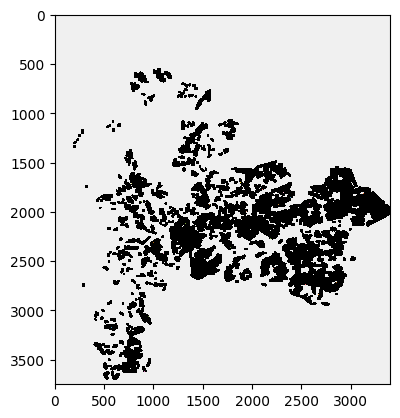

In [36]:
plt.imshow(out_image[0], utils.get_mpl_cmap(path_list[0]))

In [ ]:
for cntr_code in country_list:
    out_file = path.join(utils.intermediate_data_dir, "nuts3_crop_profile", f"{cntr_code}.geojson")
    if path.isfile(out_file):
        print(f"Output file for country {cntr_code} already exists ({out_file})")
        print("skipping...")
        continue
    print("processing country: ", cntr_code)

    temp_df = gdf_polygons[gdf_polygons["CNTR_CODE"] == cntr_code]
        
    tile_dict = {}
    tile_data = xr.DataArray()

    for row_num, (row_idx, lau) in enumerate(temp_df.iterrows()):
        if row_num % 10 == 0:
            print(f"processing row {row_num} of {len(temp_df)}")
        lau_geom = lau.geometry
        matches = tile_index.sindex.query(lau_geom, predicate="intersects")    
        path_list = tile_index.iloc[matches]["path"].values
        
        
        update_tileset = False
        # we check wether we need to load new tilesets in two steps:
        
        # remove tiles that were needed for the previous LAU, but not for this one
        drop_keys = []
        for k, v in tile_dict.items():
            if k not in path_list:
                drop_keys.append(k)
                # we remove the tile from the index, but do not update the tileset to save on compute at the cost of memory. 
                # The next time an additional tile needs to be loaded, the deleted tiles will not be part of the new raster.
                update_tileset = True
        
        for key in drop_keys:
            del tile_dict[key]
        
        # add new tiles
        for file_path in path_list:
            if file_path not in tile_dict:
                temp = rxr.open_rasterio(file_path)
                temp = temp.rio.write_nodata(0)
                tile_dict[file_path] = temp
                update_tileset = True

        if update_tileset:
            tile_data = merge_arrays(list(tile_dict.values()))
        
        if isinstance(lau_geom, Polygon):
            clipped_tile = tile_data.rio.clip([lau_geom], raster_crs, drop=True)
        elif isinstance(lau_geom, MultiPolygon):
            clipped_tile = tile_data.rio.clip(list(lau_geom.geoms), raster_crs, drop=True)

        # flatten and count
        values, counts = np.unique(clipped_tile.values, return_counts=True)

        temp_df.at[row_idx, "crop_profile"]  = dict(zip(values.tolist(), counts.tolist()))

    print("writing to file: ", out_file)
    temp_df.to_file(out_file)

Output file for country AL already exists (/Users/johannesgille/Desktop/CE_2026_4_drought/data_intermediate/nuts3_crop_profile/AL.geojson)
skipping...
processing country:  AT
processing row 0 of 35
processing row 10 of 35
processing row 20 of 35
processing row 30 of 35
writing to file:  /Users/johannesgille/Desktop/CE_2026_4_drought/data_intermediate/nuts3_crop_profile/AT.geojson
processing country:  BE
processing row 0 of 44
processing row 10 of 44
processing row 20 of 44
processing row 30 of 44
processing row 40 of 44
writing to file:  /Users/johannesgille/Desktop/CE_2026_4_drought/data_intermediate/nuts3_crop_profile/BE.geojson
processing country:  BG
processing row 0 of 28
processing row 10 of 28
processing row 20 of 28
writing to file:  /Users/johannesgille/Desktop/CE_2026_4_drought/data_intermediate/nuts3_crop_profile/BG.geojson
processing country:  CH
processing row 0 of 26
processing row 10 of 26
processing row 20 of 26
writing to file:  /Users/johannesgille/Desktop/CE_2026_4_d

KeyboardInterrupt: 

In [ ]:
clipped_tile = tile_data.rio.clip([lau_geom], raster_crs, drop=True)


In [ ]:
temp_df.at[temp_df.index[row_idx], "crop_profile"]  = dict(zip(values.tolist(), counts.tolist()))


In [ ]:
tile_data.rio.clip([lau_geom], raster_crs)

/Users/johannesgille/Desktop/CE_2026_4_drought/.venv/lib/python3.9/site-packages/xarray/core/duck_array_ops.py:237: RuntimeWarning: invalid value encountered in cast
  return data.astype(dtype, **kwargs)


<xarray.DataArray (band: 1, y: 6301, x: 6638)> Size: 84MB
array([[[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]]], dtype=uint16)
Coordinates:
  * x            (x) float64 53kB 5.138e+06 5.138e+06 ... 5.204e+06 5.204e+06
  * y            (y) float64 50kB 2.148e+06 2.148e+06 ... 2.085e+06 2.085e+06
  * band         (band) int64 8B 1
    spatial_ref  int64 8B 0
Attributes:
    AREA_OR_POINT:             Area
    STATISTICS_MAXIMUM:        65535
    STATISTICS_MEAN:           9748.96720875
    STATISTICS_MINIMUM:        0
    STATISTICS_STDDEV:         23105.84681436
    STATISTICS_VALID_PERCENT:  100
    scale_factor:              1.0
    add_offset:                0.0

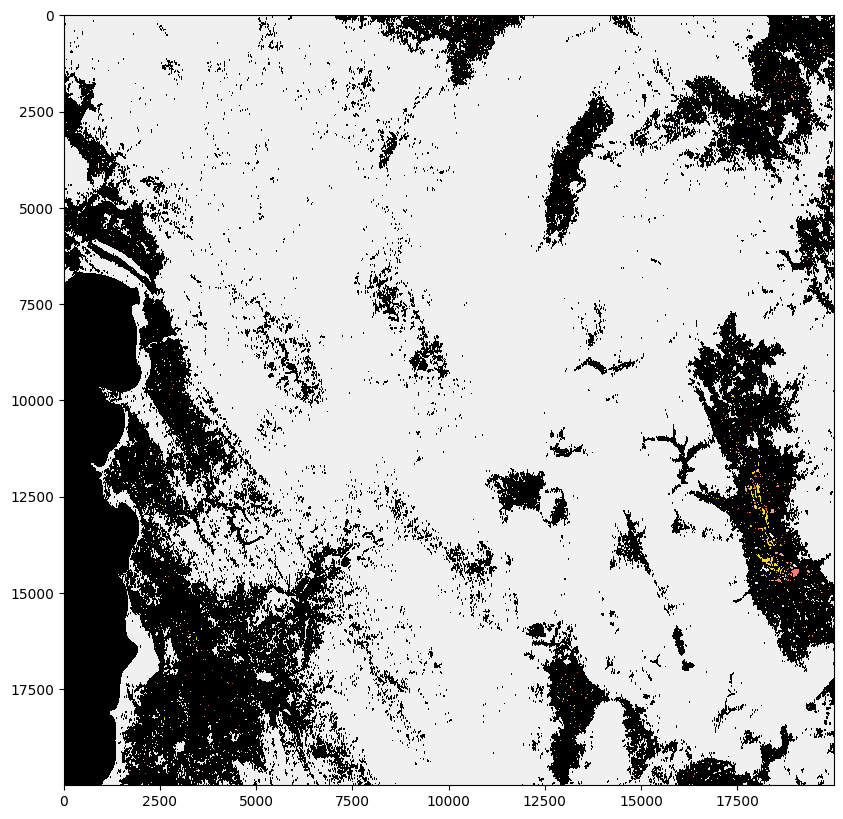

In [ ]:
fig, ax = plt.subplots(1,1, figsize=(10,10))

ax.imshow(utils.prep_copernicus_data(np.array(merged[0])), utils.get_mpl_cmap(path_list[0]))
patch = MplPolygon(list(lau_geom.exterior.coords), fill=False, edgecolor="red", linewidth=5) 

ax.add_patch(patch)
plt.show()

In [ ]:
gdf_polygons.crs

<Projected CRS: EPSG:3035>
Name: ETRS89-extended / LAEA Europe
Axis Info [cartesian]:
- [north]: Northing (metre)
- [east]: Easting (metre)
Area of Use:
- undefined
Coordinate Operation:
- name: unnamed
- method: Lambert Azimuthal Equal Area
Datum: European Terrestrial Reference System 1989
- Ellipsoid: GRS 1980
- Prime Meridian: Greenwich

In [ ]:
lau

NUTS_ID                                                   AL011
LEVL_CODE                                                     3
CNTR_CODE                                                    AL
NAME_LATN                                                 Dibër
NUTS_NAME                                                 Dibër
MOUNT_TYPE                                                  NaN
URBN_TYPE                                                   NaN
COAST_TYPE                                                  NaN
geometry      POLYGON ((5179983.543990663 2144882.936605058,...
Name: 0, dtype: object

In [ ]:
type(lau.geometry.exterior.coords)

shapely.coords.CoordinateSequence

/var/folders/1_/j9jx95wx4zv29v6wh_ztx5_r0000gp/T/ipykernel_85535/2873271498.py:11: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  plt.legend()


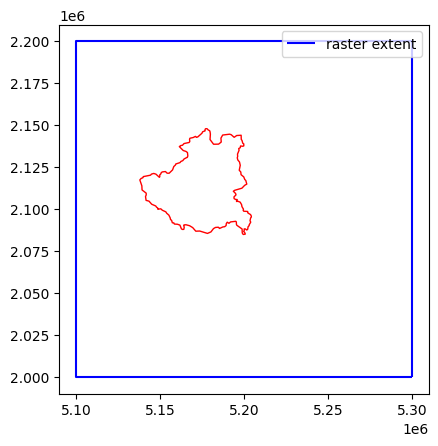

In [ ]:
# Create a box from the raster bounds and see if it matches your shape visually
raster_bbox = box(*merged.rio.bounds())
raster_gdf = gpd.GeoDataFrame(geometry=[raster_bbox], crs=merged.rio.crs)

fig, ax = plt.subplots()
# merged.sel(band=1).plot(ax=ax)
raster_gdf.to_crs(merged.rio.crs).boundary.plot(ax=ax, color="blue", label="raster extent")
b = gpd.GeoSeries(lau.geometry)
b.set_crs(merged.rio.crs)
b.plot(ax=ax, facecolor="none", edgecolor="red", label="shape")
plt.legend()
plt.show()

In [ ]:
for i, t in enumerate(tiles):
    print(f"Band {i+1} pixel height:", t.rio.transform()[4])

Band 1 pixel height: -10.0
Band 2 pixel height: -10.0
Band 3 pixel height: -10.0
Band 4 pixel height: -10.0


MergeError: Rasters with negative pixel height ("upside down" rasters) cannot be merged.

In [ ]:
lau.geometry.area

6464816.20324744

In [ ]:
area = result
del area[0]
print(sum(area.values))

TypeError: 'builtin_function_or_method' object is not iterable

In [ ]:
len(set(candidate_tiles["path"].values))

57

In [ ]:
de_geom = unary_union(de_gdf.geometry)

In [ ]:

def load_clip(path, geom):
    da = rxr.open_rasterio(path, masked=True)
    return da.rio.clip([geom], raster_crs)


In [ ]:
candidate_tiles.path.values

array(['/Users/johannesgille/Desktop/CE_2026_4_drought/data/Crop_Types/CLMS_HRLVLCC_CTY_S2023_R10m_E43N34_03035_V01_R00/CLMS_HRLVLCC_CTY_S2023_R10m_E43N34_03035_V01_R00.tif',
       '/Users/johannesgille/Desktop/CE_2026_4_drought/data/Crop_Types/CLMS_HRLVLCC_CTY_S2023_R10m_E43N34_03035_V01_R00/CLMS_HRLVLCC_CTY_S2023_R10m_E43N34_03035_V01_R00.tif',
       '/Users/johannesgille/Desktop/CE_2026_4_drought/data/Crop_Types/CLMS_HRLVLCC_CTY_S2023_R10m_E42N34_03035_V01_R00/CLMS_HRLVLCC_CTY_S2023_R10m_E42N34_03035_V01_R00.tif',
       ...,
       '/Users/johannesgille/Desktop/CE_2026_4_drought/data/Crop_Types/CLMS_HRLVLCC_CTY_S2023_R10m_E44N30_03035_V01_R00/CLMS_HRLVLCC_CTY_S2023_R10m_E44N30_03035_V01_R00.tif',
       '/Users/johannesgille/Desktop/CE_2026_4_drought/data/Crop_Types/CLMS_HRLVLCC_CTY_S2023_R10m_E44N30_03035_V01_R00/CLMS_HRLVLCC_CTY_S2023_R10m_E44N30_03035_V01_R00.tif',
       '/Users/johannesgille/Desktop/CE_2026_4_drought/data/Crop_Types/CLMS_HRLVLCC_CTY_S2023_R10m_E44N30_03035_V

In [ ]:
candidate_tiles_paths = set(candidate_tiles["path"].values)

tile_data = []
for i,t in enumerate(candidate_tiles_paths):
    if i%5 == 0:
        print(f"loading tile {i} of {len(candidate_tiles_paths)}")
    tile_data.append(load_clip(t, de_geom))


loading tile 0 of 57
loading tile 5 of 57
loading tile 10 of 57
loading tile 15 of 57
loading tile 20 of 57
loading tile 25 of 57
loading tile 30 of 57
loading tile 35 of 57
loading tile 40 of 57
loading tile 45 of 57
loading tile 50 of 57
loading tile 55 of 57


In [ ]:
tile_data = xr.concat(tile_data, dim="band")


: 

In [ ]:
de_gdf.bounds["minx"].min()

np.float64(4031373.8217481286)

In [ ]:
import rasterio
from rasterio.windows import from_bounds

arrays = []

bounds = de_gdf.bounds

for _, row in candidate_tiles.iterrows():
    with rasterio.open(row.path) as src:
        window = from_bounds(left=bounds["minx"].min(), bottom=bounds["miny"].min(), right=bounds["maxx"].max(), top=bounds["maxy"].max(), transform=src.transform)
        # window = from_bounds(, transform=src.transform)
        data = src.read(1, window=window)
        arrays.append((data, window, src.transform))


KeyboardInterrupt: 

In [ ]:
from rasterio.merge import merge

datasets = [rasterio.open(row.path) for _, row in candidate_tiles.iterrows()]
merged, merged_transform = merge(datasets, bounds=aoi.bounds)
